### Analiza głownych grup użytkowników

Można spróbować znaleźć pewne grupy podobnych rowerzystów - porannych kolarzy do pracy, albo rekreacyjnych wieczorem. Mozemy sprawdzic jak zachowuja sie oni zlaeznie od pory dnia i pogody

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Wczytanie danych
df_ml = pd.read_csv('data/processed/citi_bike_ml_ready.csv')

# 2. Przygotowanie cech (Godzina, Dzień, Czas, Temp, Deszcz)
features = ['hour', 'day_of_week', 'duration_min', 'temp_max_C', 'precipitation_mm']
X = df_ml[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. K-Means (4 klastry - żeby wyłapać też klastry pogodowe)
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
df_ml['cluster'] = kmeans.fit_predict(X_scaled)

print("Klastry zostały przypisane")

Klastry zostały przypisane


C:\Users\Antek\AppData\Local\Temp\ipykernel_28884\382638666.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ml, x='cluster', y='duration_min', palette='tab10', showfliers=False)


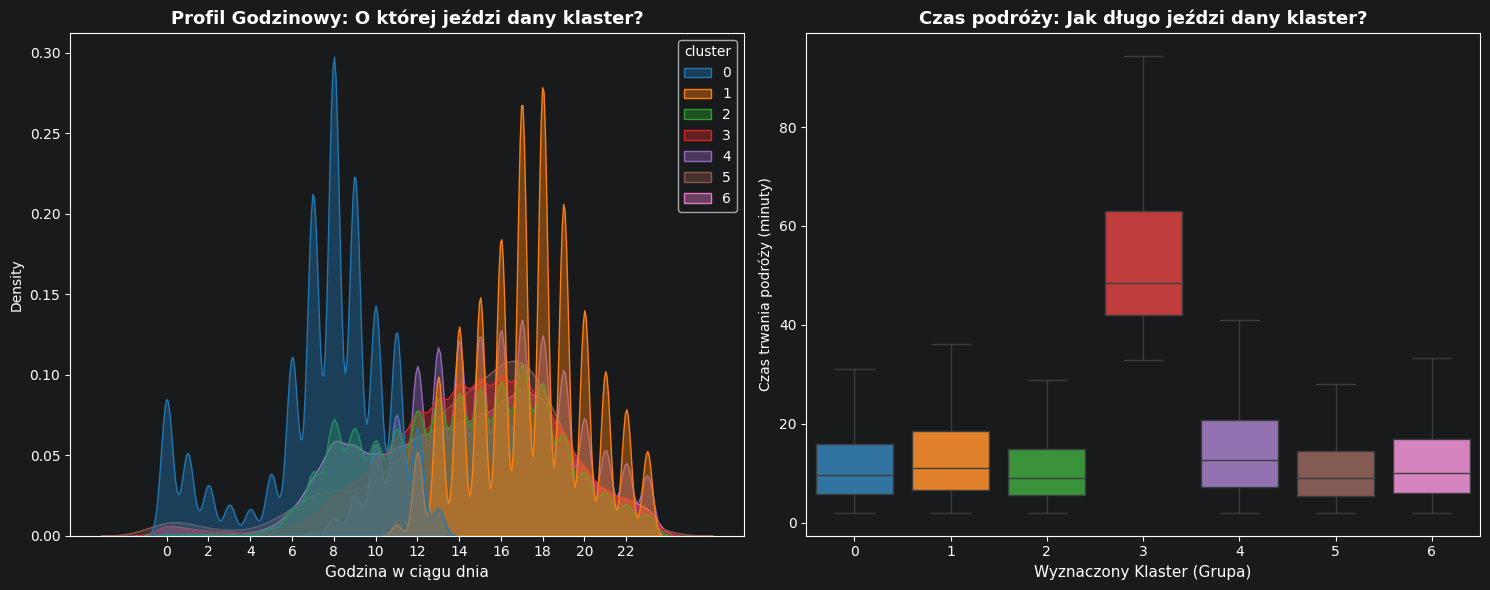

In [27]:
plt.figure(figsize=(15, 6))

# Wykres A: Kiedy jeżdżą? (Gęstość godzinowa)
plt.subplot(1, 2, 1)
sns.kdeplot(data=df_ml, x='hour', hue='cluster', fill=True, palette='tab10', common_norm=False, alpha=0.4)
plt.title('Profil Godzinowy: O której jeździ dany klaster?', fontsize=13, fontweight='bold')
plt.xlabel('Godzina w ciągu dnia', fontsize=11)
plt.xticks(range(0, 24, 2))

# Wykres B: Jak długo jeżdżą? (Boxplot czasu trwania)
plt.subplot(1, 2, 2)
sns.boxplot(data=df_ml, x='cluster', y='duration_min', palette='tab10', showfliers=False)
plt.title('Czas podróży: Jak długo jeździ dany klaster?', fontsize=13, fontweight='bold')
plt.xlabel('Wyznaczony Klaster (Grupa)', fontsize=11)
plt.ylabel('Czas trwania podróży (minuty)')

plt.tight_layout()
plt.savefig('klastry_godzina.png', dpi=300, bbox_inches='tight')
plt.show()

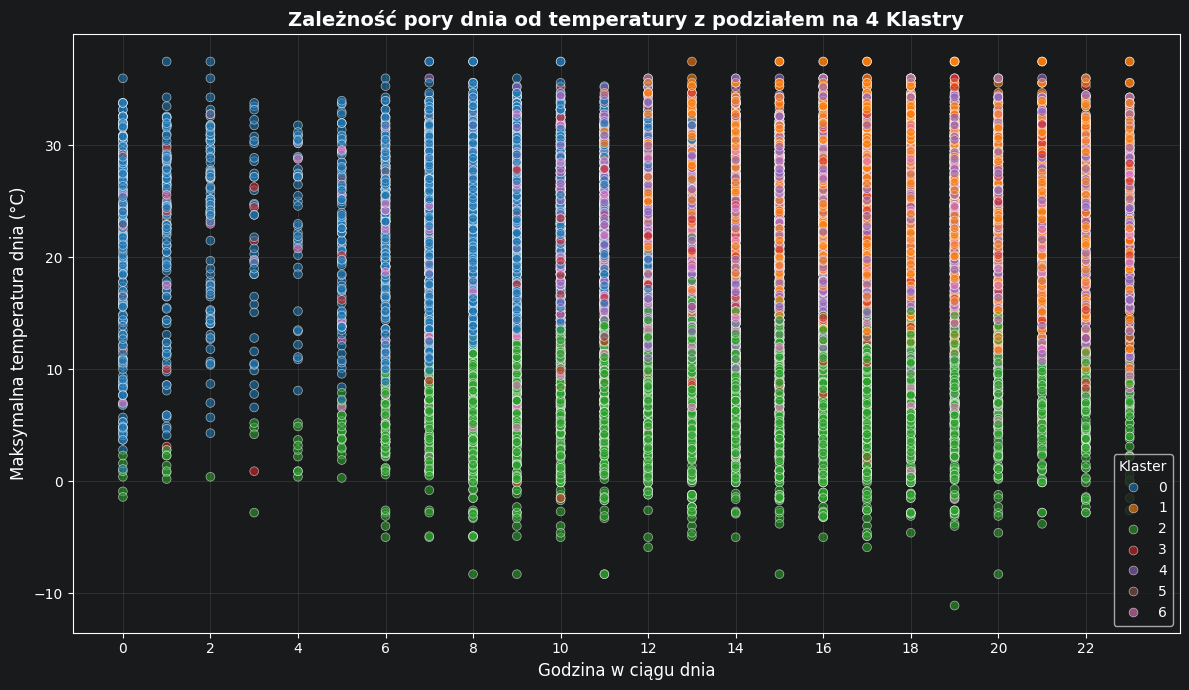

In [28]:
plt.figure(figsize=(12, 7))

# Losujemy próbkę 20k punktów, żeby wykres był czytelny i szybki
df_sample = df_ml.sample(n=min(20000, len(df_ml)), random_state=42)

sns.scatterplot(
    data=df_sample,
    x='hour',
    y='temp_max_C',
    hue='cluster',
    palette='tab10',
    alpha=0.6,
    s=40
)

plt.title('Zależność pory dnia od temperatury z podziałem na 4 Klastry', fontsize=14, fontweight='bold')
plt.xlabel('Godzina w ciągu dnia', fontsize=12)
plt.ylabel('Maksymalna temperatura dnia (°C)', fontsize=12)
plt.xticks(range(0, 24, 2))
plt.grid(True, alpha=0.2)
plt.legend(title='Klaster', loc='lower right')
plt.tight_layout()
plt.savefig('klastry_pogoda.png', dpi=300, bbox_inches='tight')

plt.show()

<Figure size 1200x600 with 0 Axes>

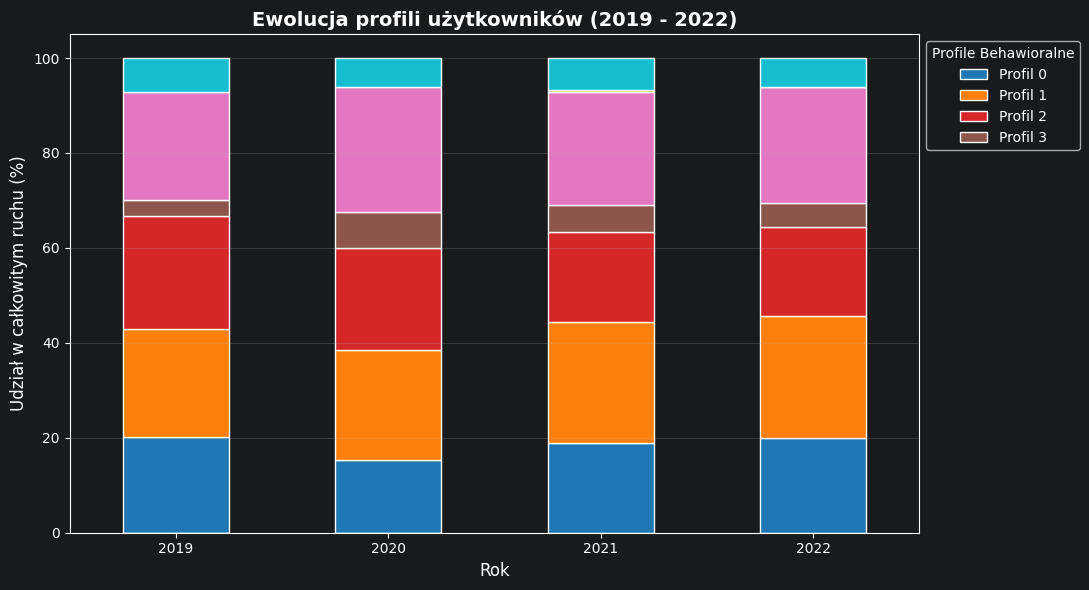


Tabela udziałów procentowych [%]:
cluster     0     1     2    3     4    5    6
year                                          
2019     20.2  22.7  23.9  3.4  22.9  NaN  7.0
2020     15.2  23.2  21.5  7.6  26.4  NaN  6.1
2021     19.0  25.3  19.1  5.6  23.9  0.3  6.8
2022     20.0  25.7  18.7  5.1  24.3  0.2  6.0


In [29]:
# Obliczamy udziały procentowe klastrów w każdym roku
cluster_evolution = df_ml.groupby(['year', 'cluster']).size().unstack()
cluster_evolution_pct = cluster_evolution.apply(lambda x: x / x.sum() * 100, axis=1)

# Wykres słupkowy skumulowany - ZMIANA: cmap='tab10' zamiast 'viridis'
plt.figure(figsize=(12, 6))
cluster_evolution_pct.plot(kind='bar', stacked=True, figsize=(11, 6), cmap='tab10', edgecolor='white')

plt.title('Ewolucja profili użytkowników (2019 - 2022)', fontsize=14, fontweight='bold')
plt.xlabel('Rok', fontsize=12)
plt.ylabel('Udział w całkowitym ruchu (%)', fontsize=12)
plt.legend(title='Profile Behawioralne', labels=['Profil 0', 'Profil 1', 'Profil 2', 'Profil 3'], bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('klastry_rok.png', dpi=300, bbox_inches='tight')

plt.show()

print("\nTabela udziałów procentowych [%]:")
print(cluster_evolution_pct.round(1))

Obliczanie inercji dla różnej liczby klastrów (szukanie idealnego 'k')...


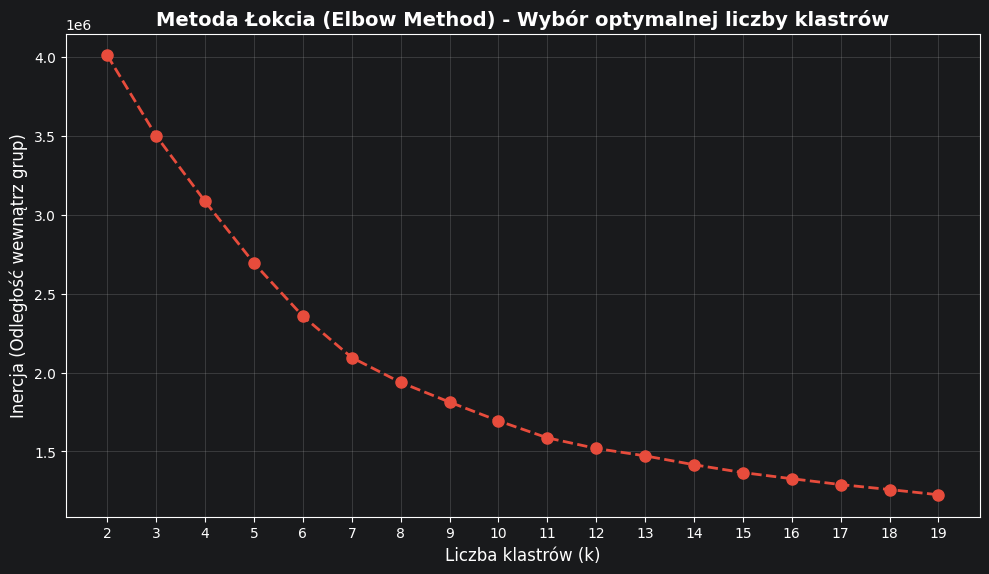

In [25]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Zakładam, że masz już przygotowaną zmienną X_scaled z poprzednich komórek
inertia = []
K_range = range(2, 20) # Sprawdzamy od 2 do 9 klastrów

print("Obliczanie inercji dla różnej liczby klastrów (szukanie idealnego 'k')...")
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertia.append(kmeans_temp.inertia_)

# Rysowanie wykresu Metody Łokcia
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='#e74c3c', linewidth=2, markersize=8)

plt.title('Metoda Łokcia (Elbow Method) - Wybór optymalnej liczby klastrów', fontsize=14, fontweight='bold')
plt.xlabel('Liczba klastrów (k)', fontsize=12)
plt.ylabel('Inercja (Odległość wewnątrz grup)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.show()